# Proyek Akhir: Menyelesaikan Permasalahan Dropout Siswa di Jaya Jaya Institut

## Business Understanding

Jaya Jaya Institut adalah institusi pendidikan perguruan tinggi yang telah berdiri sejak tahun 2000. Meskipun telah mencetak banyak lulusan berkualitas, institusi menghadapi masalah tingkat dropout (siswa tidak menyelesaikan pendidikan) yang cukup tinggi.

### Permasalahan Bisnis
1. Berapa besar proporsi siswa yang dropout, enrolled (masih aktif), dan graduate (lulus)?
2. Faktor-faktor apa saja (akademik, finansial, demografis) yang paling berkontribusi terhadap risiko dropout?
3. Bagaimana cara mendeteksi siswa berisiko dropout sedini mungkin agar dapat diberikan bimbingan khusus?

### Cakupan Proyek
1. Melakukan exploratory data analysis (EDA) terhadap data performa siswa.
2. Membangun model machine learning untuk memprediksi probabilitas siswa melakukan dropout.
3. Membuat business dashboard untuk memonitor performa siswa secara berkelanjutan.
4. Membangun prototype sistem prediksi (Streamlit) yang siap digunakan oleh tim akademik/BK Jaya Jaya Institut.
5. Memberikan rekomendasi action items berbasis data.

### Persiapan
Sumber data: [Students' Performance Dataset - Dicoding](https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance) (UCI Machine Learning Repository, Realinho et al., 2021).

Environment setup:
```
pip install -r requirements.txt
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
import joblib, json

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)


## Data Understanding

Dataset berisi 4.424 baris data siswa dengan 36 fitur (akademik, demografis, sosial-ekonomi) dan 1 kolom target `Status` (Dropout / Enrolled / Graduate).

In [2]:
df = pd.read_csv('data.csv', sep=';', encoding='utf-8-sig')
print(df.shape)
df.head()

(4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
df.isna().sum().sum()  # cek missing value

0

In [5]:
df['Status'].value_counts()

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

C:\Users\POJ\AppData\Local\Temp\ipykernel_21652\395294469.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', order=df['Status'].value_counts().index, palette='viridis')


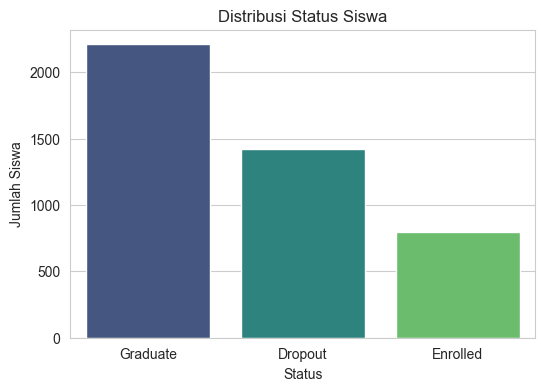

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Status', order=df['Status'].value_counts().index, palette='viridis')
plt.title('Distribusi Status Siswa')
plt.ylabel('Jumlah Siswa')
plt.show()

**Insight:** Sekitar 32% siswa berstatus Dropout, 50% Graduate, dan 18% masih Enrolled. Tingkat dropout ini cukup signifikan bagi institusi dan menjadi fokus utama pemodelan.

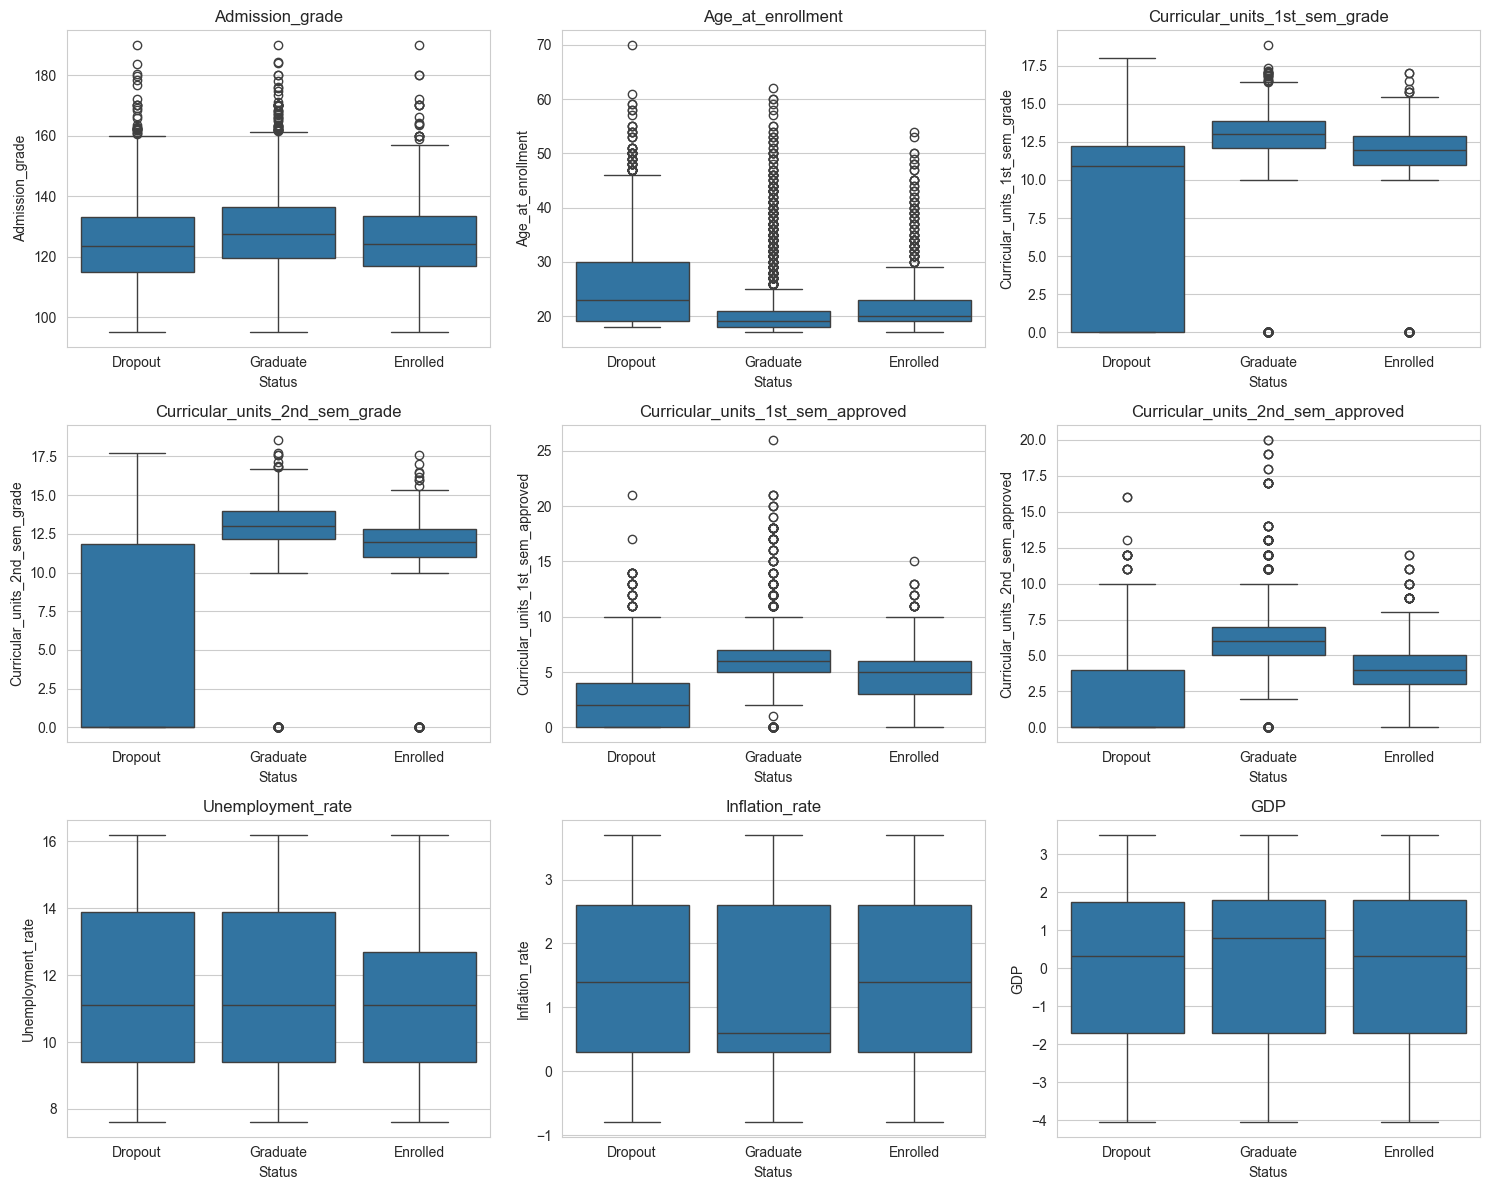

In [7]:
num_cols = ['Admission_grade','Age_at_enrollment','Curricular_units_1st_sem_grade',
            'Curricular_units_2nd_sem_grade','Curricular_units_1st_sem_approved',
            'Curricular_units_2nd_sem_approved','Unemployment_rate','Inflation_rate','GDP']
fig, axes = plt.subplots(3,3, figsize=(15,12))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x='Status', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Insight:**
- Siswa dropout cenderung memiliki jumlah mata kuliah *approved* dan rata-rata nilai (grade) semester 1 & 2 yang jauh lebih rendah dibanding siswa graduate.
- Siswa dropout cenderung sedikit lebih tua saat mendaftar.
- Faktor makroekonomi (unemployment, inflation, GDP) berpengaruh relatif kecil dibanding faktor akademik individu.

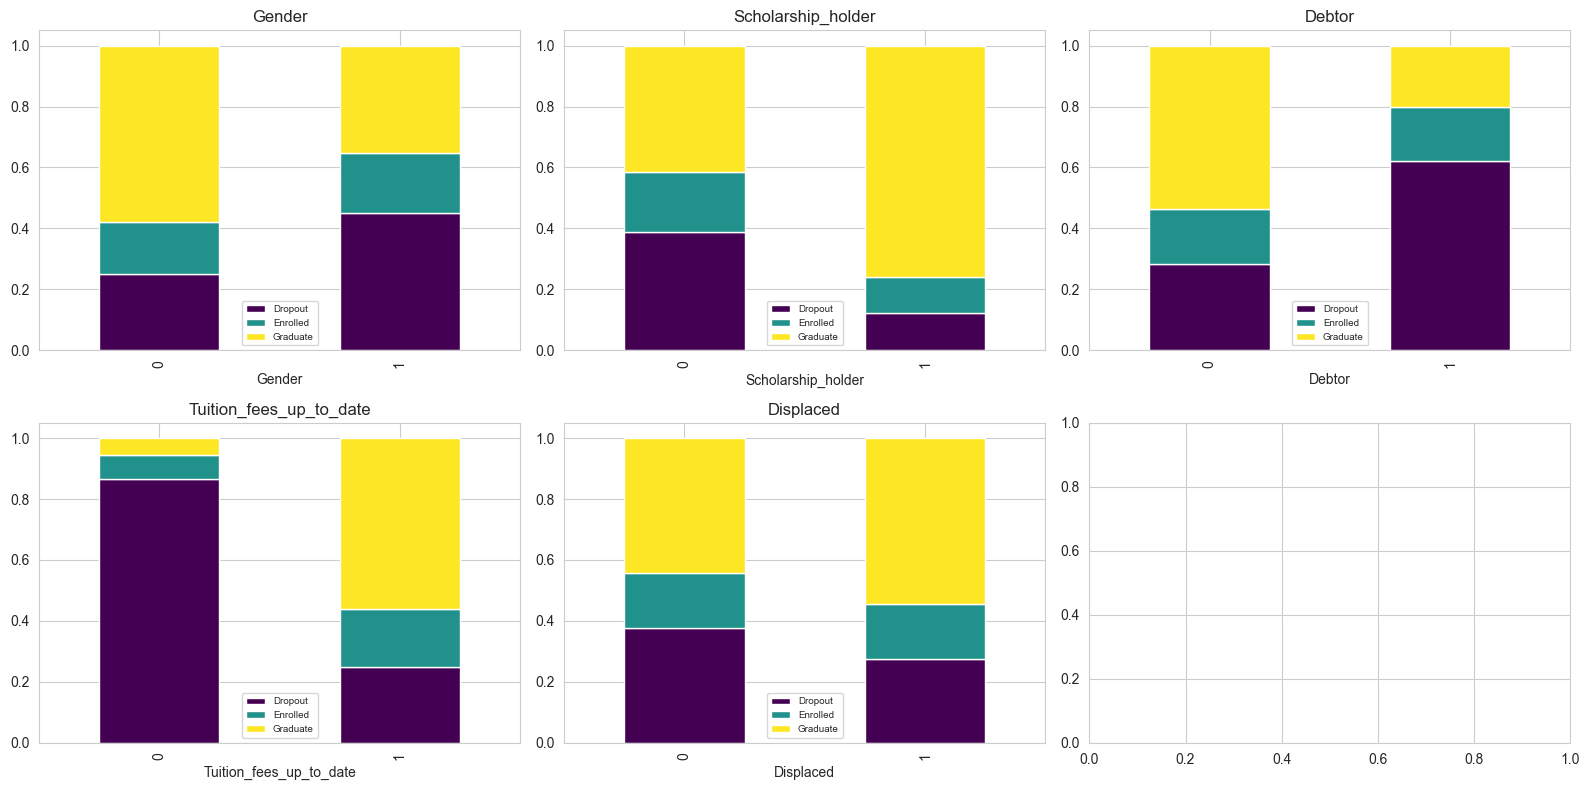

In [8]:
cat_cols = ['Gender','Scholarship_holder','Debtor','Tuition_fees_up_to_date','Displaced']
fig, axes = plt.subplots(2,3, figsize=(16,8))
for ax, col in zip(axes.flatten(), cat_cols):
    ct = pd.crosstab(df[col], df['Status'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

**Insight:**
- Siswa dengan status `Debtor = 1` (punya tunggakan) dan `Tuition_fees_up_to_date = 0` (SPP belum lunas) memiliki proporsi dropout jauh lebih tinggi.
- Penerima beasiswa (`Scholarship_holder = 1`) memiliki proporsi dropout lebih rendah.
- Faktor finansial terbukti menjadi salah satu pendorong dropout yang penting, selain performa akademik.

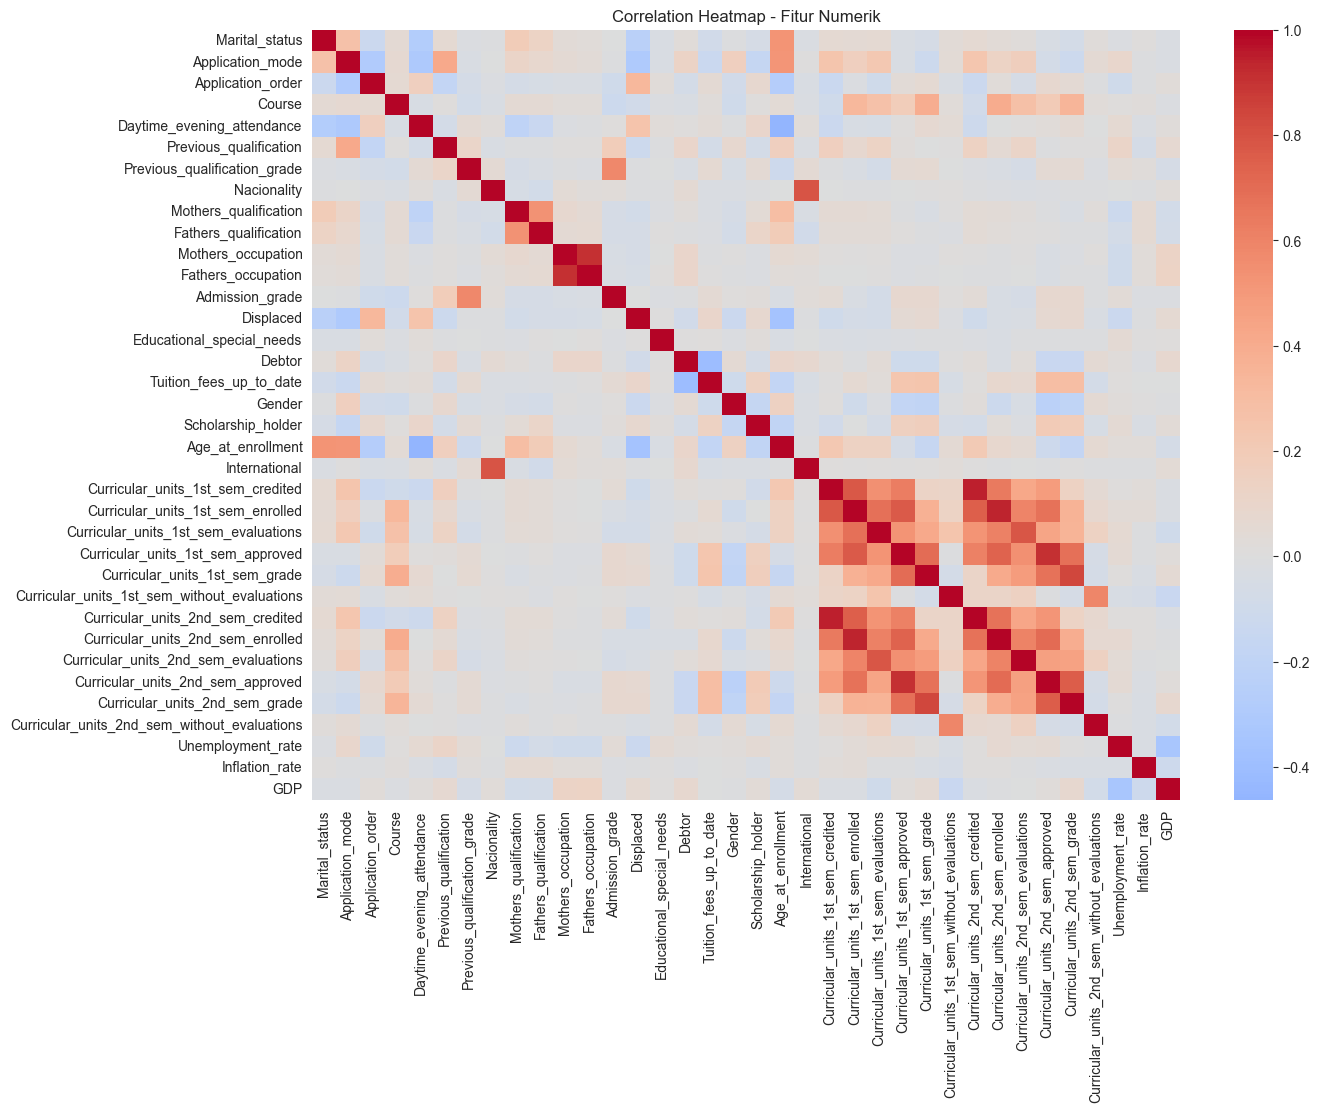

In [9]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Fitur Numerik')
plt.show()

## Data Preparation / Preprocessing

Permasalahan dirumuskan sebagai **klasifikasi biner**: `Dropout` vs `Non-Dropout` (gabungan Enrolled & Graduate). Pendekatan ini dipilih karena tujuan bisnis utama adalah mendeteksi siswa berisiko dropout sedini mungkin untuk intervensi, sehingga label Enrolled (masih berjalan, belum tentu lulus/dropout) digabung sebagai kelas "belum dropout".

Tahapan:
1. Encode target menjadi `Dropout_Flag` (1 = Dropout, 0 = Non-Dropout).
2. Split data 80:20 (train:test) dengan stratifikasi.
3. Standardisasi fitur numerik dengan `StandardScaler`.


In [10]:
df['Dropout_Flag'] = (df['Status'] == 'Dropout').astype(int)
X = df.drop(columns=['Status','Dropout_Flag'])
y = df['Dropout_Flag']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(X_train.shape, X_test.shape)

(3539, 36) (885, 36)


## Modeling

Dua model dibandingkan sebagai baseline dan model utama:
1. **Logistic Regression** (baseline, interpretable)
2. **Random Forest Classifier** (model utama, menangani non-linearitas & interaksi fitur, serta memberi feature importance)

`class_weight='balanced'` digunakan untuk menangani sedikit ketidakseimbangan kelas.

In [11]:
log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_s, y_train)
pred_lr = log_reg.predict(X_test_s)
print('=== Logistic Regression ===')
print(classification_report(y_test, pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, log_reg.predict_proba(X_test_s)[:,1]))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       601
           1       0.79      0.83      0.81       284

    accuracy                           0.87       885
   macro avg       0.85      0.86      0.86       885
weighted avg       0.88      0.87      0.87       885

ROC-AUC: 0.9271753650019919


In [12]:
rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight='balanced')
rf.fit(X_train_s, y_train)
pred_rf = rf.predict(X_test_s)
print('=== Random Forest ===')
print(classification_report(y_test, pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, rf.predict_proba(X_test_s)[:,1]))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       601
           1       0.88      0.76      0.81       284

    accuracy                           0.89       885
   macro avg       0.88      0.85      0.87       885
weighted avg       0.89      0.89      0.89       885

ROC-AUC: 0.9290033043519017


**Insight:** Random Forest memberikan performa lebih baik dibanding Logistic Regression (F1-score dan ROC-AUC lebih tinggi), sehingga dipilih sebagai model final.

## Evaluation

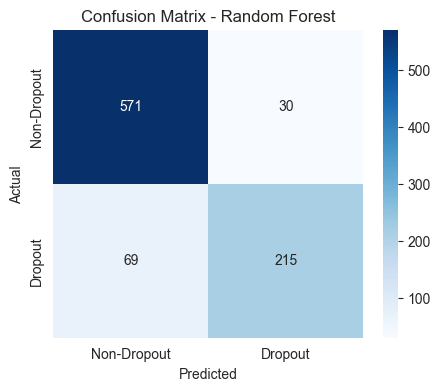

Accuracy: 0.888135593220339
F1-score: 0.8128544423440454


In [13]:
cm = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Dropout','Dropout'], yticklabels=['Non-Dropout','Dropout'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

print('Accuracy:', accuracy_score(y_test, pred_rf))
print('F1-score:', f1_score(y_test, pred_rf))

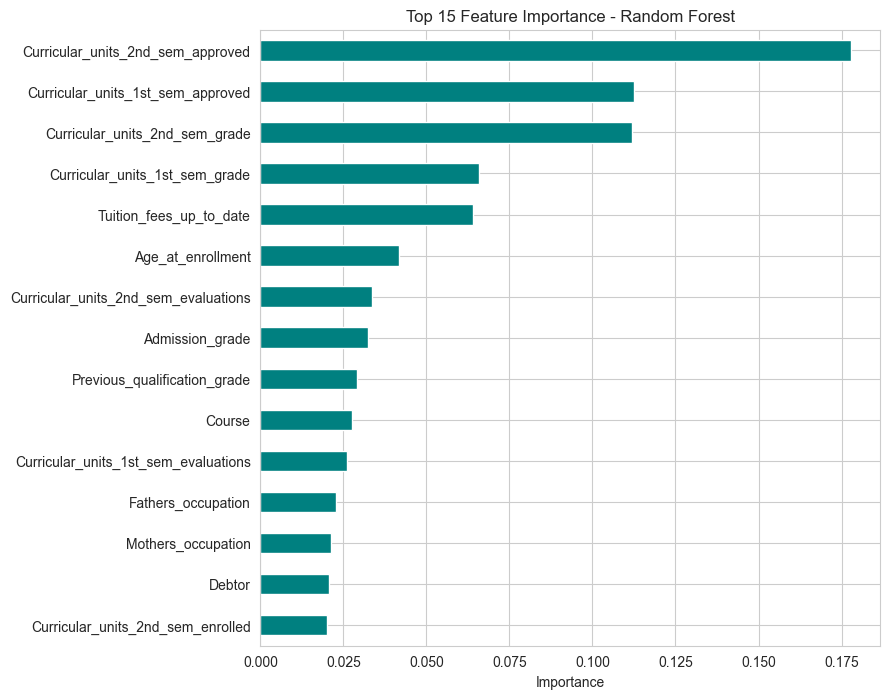

Curricular_units_2nd_sem_approved       0.177793
Curricular_units_1st_sem_approved       0.112512
Curricular_units_2nd_sem_grade          0.111898
Curricular_units_1st_sem_grade          0.065700
Tuition_fees_up_to_date                 0.064124
Age_at_enrollment                       0.041825
Curricular_units_2nd_sem_evaluations    0.033763
Admission_grade                         0.032543
Previous_qualification_grade            0.029171
Course                                  0.027502
Curricular_units_1st_sem_evaluations    0.026040
Fathers_occupation                      0.022864
Mothers_occupation                      0.021338
Debtor                                  0.020665
Curricular_units_2nd_sem_enrolled       0.020101
dtype: float64

In [14]:
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(8,8))
importances.head(15).sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()
importances.head(15)

**Insight Utama:**
1. `Curricular_units_2nd_sem_approved` dan `Curricular_units_1st_sem_approved` (jumlah mata kuliah lulus) adalah prediktor terkuat — semakin sedikit mata kuliah yang lulus di semester awal, semakin tinggi risiko dropout.
2. Nilai rata-rata semester 1 & 2 (`grade`) juga sangat berpengaruh.
3. `Tuition_fees_up_to_date` (status pembayaran SPP) merupakan fitur finansial paling berpengaruh — siswa yang menunggak SPP jauh lebih berisiko dropout.
4. `Age_at_enrollment`, `Admission_grade`, dan `Previous_qualification_grade` turut berkontribusi, menandakan kesiapan akademik awal penting untuk dipantau.

Model Random Forest final mencapai **akurasi ~89%** dan **F1-score ~0.81** pada data uji, cukup andal untuk digunakan sebagai alat bantu deteksi dini (early warning system), meski tetap perlu direview oleh staf akademik sebelum pengambilan keputusan.

## Menyimpan Model untuk Deployment

Model, scaler, dan daftar nama fitur disimpan agar dapat dimuat oleh prototype Streamlit (`app.py`).

In [15]:
import os
os.makedirs('model', exist_ok=True)
joblib.dump(rf, 'model/model.joblib')
joblib.dump(scaler, 'model/scaler.joblib')
with open('model/feature_names.json','w') as f:
    json.dump(feature_names, f)
print('Model artifacts saved to ./model/')

Model artifacts saved to ./model/


## Conclusion

Berdasarkan analisis data dan pemodelan yang dilakukan:

1. **Tingkat dropout Jaya Jaya Institut cukup tinggi (~32%)** dari total siswa dalam dataset, menjadikannya masalah prioritas.
2. **Faktor akademik pada semester awal** (jumlah mata kuliah yang berhasil diselesaikan dan nilai rata-rata di semester 1 & 2) adalah prediktor dropout paling kuat. Siswa yang kesulitan di semester-semester awal berisiko tinggi dropout.
3. **Faktor finansial** — status pembayaran SPP yang tidak lancar dan status debtor — juga berkontribusi signifikan terhadap risiko dropout.
4. **Beasiswa terbukti membantu retensi siswa**, terlihat dari proporsi dropout yang lebih rendah pada penerima beasiswa.
5. Model **Random Forest** yang dibangun mampu memprediksi risiko dropout siswa dengan **akurasi ~89% dan F1-score ~0.81**, sehingga layak digunakan sebagai alat bantu deteksi dini bagi tim akademik.

Model dan dashboard yang dihasilkan pada proyek ini menjawab kebutuhan Jaya Jaya Institut untuk mendeteksi siswa berisiko dropout secara lebih cepat dan berbasis data, sehingga bimbingan khusus dapat diberikan secara lebih tepat sasaran.

Rekomendasi action items selengkapnya tersedia pada berkas `README.md`.
